In [1]:
#import libraries
import numpy as np
from ase.io import read, write
from ase import Atoms
import torch
import yaml
import json
import matplotlib.pyplot as plt
import pandas as pd
import os
import sys
import re
import functions as f #import functions used in this notebook

c:\Users\Hirayama-Lab\.conda\envs\mace_gpu_test\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [45]:
#variable setup
name = "Fe_Si_B_260311"
type = 'rnd_e'
#setting the model name based on model number and epochs
device = 'cuda'
model = "MACE-matpes-pbe-omat-ft"
model_id = 'matpes_nofe8b4'
learning_rate = 1e-4
num_epoch = 80 #number of epochs used for training
batch_size = 10 #batch size for training
folder = f'{model_id}_{learning_rate}_{num_epoch}_{batch_size}_{type}'
path = f'model_{name}/fine_tuning/{folder}'
train_file = f"model_{name}/train_{type}.xyz"
test_file = f"model_{name}/test_{type}.xyz"
model_name = f'model_{type}_{model_id}_lr{learning_rate}_{num_epoch}_{batch_size}'
os.makedirs(path, exist_ok=True)
os.makedirs(f'{path}/img_res', exist_ok=True)
os.makedirs(f'{path}/test_res', exist_ok=True)
model_name

'model_rnd_e_matpes_nofe8b4_lr0.0001_80_10'

In [46]:
path

'model_Fe_Si_B_260311/fine_tuning/matpes_nofe8b4_0.0001_80_10_rnd_e'

In [47]:
#setting new names for the training and test files
structure = 'Fe8B4'
train_file = f"model_{name}/train_{type}_no_{structure}.xyz"
test_file = f"model_{name}/test_{type}_no_{structure}.xyz"

In [48]:
train_file

'model_Fe_Si_B_260311/train_rnd_e_no_Fe8B4.xyz'

In [49]:
#this writes the yml file
config = {
    'foundation_model': f'{model}.model',
    'multiheads_finetuning': False,
    "name": model_name,
    "model_dir": path,
    "log_dir": f"{path}/log",
    "checkpoints_dir": f"{path}/checkpoints",
    "results_dir": f"{path}/results",
    "train_file": train_file,
    "valid_fraction": 0.1,
    "test_file": test_file,
    "energy_key": "REF_energy",
    "forces_key": "REF_forces",
    "batch_size": batch_size,
    "max_num_epochs": num_epoch,
    "lr":learning_rate,
    "device": device,
    "seed": 123
}
with open(f"model_{name}/config_fine_tuning.yml", "w") as f:
    yaml.dump(config, f, sort_keys=False)

In [50]:
#Perform training
import warnings
warnings.filterwarnings('ignore')
from mace.cli.run_train import main as mace_run_train_main
import sys
import logging

#defining the training function
def train_mace(config_file_path):
    logging.getLogger().handlers.clear()
    sys.argv = ['program', '--config', config_file_path]
    mace_run_train_main()

#calling the function
train_mace(f'model_{name}/config_fine_tuning.yml') # use the name of the config file that was created

2026-04-15 10:54:57.210 INFO: ===========VERIFYING SETTINGS===========
2026-04-15 10:54:57.211 INFO: MACE version: 0.3.14
2026-04-15 10:54:57.212 INFO: CUDA version: 12.6, CUDA device: 0


2026-04-15 10:54:57.443 INFO: Using foundation model MACE-matpes-pbe-omat-ft.model as initial checkpoint.
2026-04-15 10:54:57.443 WARNING: Using multiheads finetuning with a foundation model that is not a Materials Project model, need to provied a path to a pretraining file with --pt_train_file.
2026-04-15 10:54:57.443 INFO: ===========LOADING INPUT DATA===========
2026-04-15 10:54:57.443 INFO: Using heads: ['Default']
2026-04-15 10:54:57.443 INFO: Using the key specifications to parse data:
2026-04-15 10:54:57.443 INFO: Default: KeySpecification(info_keys={'energy': 'REF_energy', 'stress': 'REF_stress', 'virials': 'REF_virials', 'dipole': 'dipole', 'head': 'head', 'elec_temp': 'elec_temp', 'total_charge': 'total_charge', 'polarizability': 'polarizability', 'total_spin': 'total_spin'}, arrays_keys={'forces': 'REF_forces', 'charges': 'REF_charges'})
2026-04-15 10:54:57.443 INFO: =============    Processing head Default     ===========
2026-04-15 10:54:57.729 INFO: Using isolated atom en

In [51]:
#reading the information on the results file
results = f'{path}/results/{model_name}_run-123_train.txt' #reading the file where the training results is stored
data = [] #where the data from the 'results' file will be stored
with open(results, 'r') as f:
    for line in f:
        try:
            data.append(json.loads(line))
        except json.JSONDecodeError:
            continue
results

'model_Fe_Si_B_260311/fine_tuning/matpes_nofe8b4_0.0001_80_10_rnd_e/results/model_rnd_e_matpes_nofe8b4_lr0.0001_80_10_run-123_train.txt'

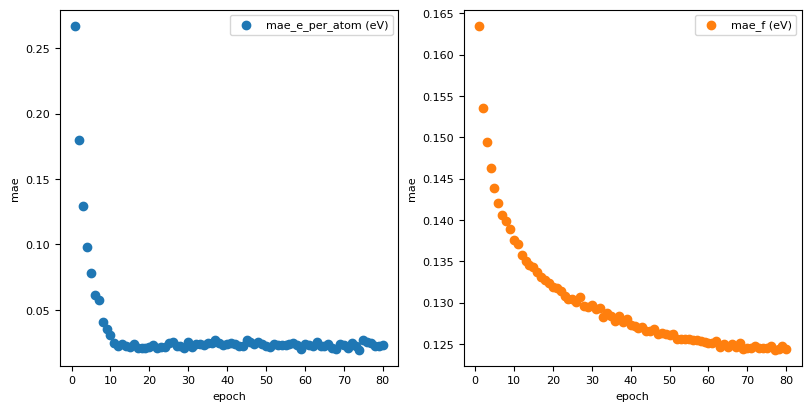

In [52]:
df = pd.DataFrame(data)
#separating the training and validation results
train_df = df[df['mode']=='opt'].copy()
val_df = df[df['mode']=='eval'].copy().dropna()
#train_df = train_df.groupby('epoch', as_index=False)['loss'].last()
train_df = train_df.groupby('epoch', as_index=False)['loss'].mean()
train_df['epoch'] += 1
val_df['epoch'] += 1

#plotting the dataframe
import functions as f
f.plot_mae(val_df, 'epoch', ['mae_e_per_atom','mae_f'])

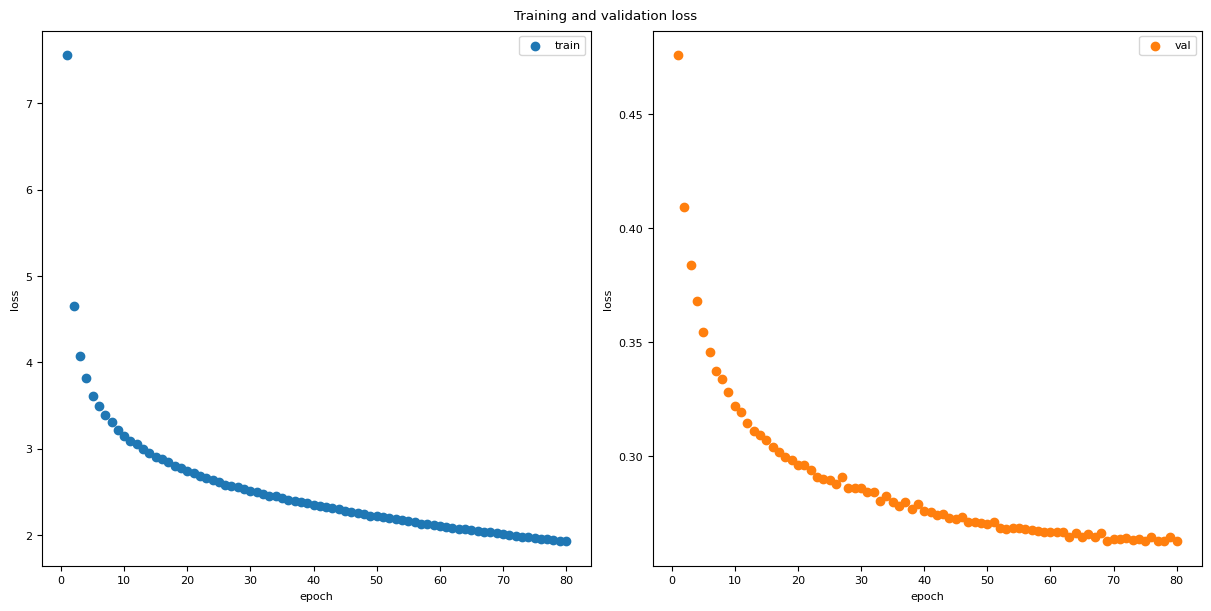

In [53]:
f.plot_loss([(train_df, 'train'),(val_df,'val')],'epoch','loss',model_name, path)

In [54]:
#evaluation
from mace.cli.eval_configs import main as mace_eval_configs_main
import sys

def eval_mace(model, configs, output, device=device):
    #agregue esto para liberar memoria (a ver que tal)
    if device == 'cuda':
        torch.cuda.empty_cache()
        batch_size = '1'
 
    sys.argv=['program', '--configs', configs, '--model', model, '--output', output, '--device', device, '--batch_size', batch_size]
    mace_eval_configs_main()

In [55]:
#print(f'{path}/{model_name}.model')
#print(f'{path}/test_res/{model_name}_test.xyz')

In [56]:
#evaluating the set on both the training and test datasets
eval_mace(model=f'{path}/{model_name}.model',
          configs=train_file,
          output=f'{path}/test_res/{model_name}_train.xyz')

eval_mace(model=f'{path}/{model_name}.model',
          configs=test_file,
          output=f'{path}/test_res/{model_name}_test.xyz')

2026-04-15 12:25:54.091 INFO: CUDA version: 12.6, CUDA device: 0
2026-04-15 12:26:38.165 INFO: CUDA version: 12.6, CUDA device: 0


In [57]:
test_df = f.eval_read(model_name, 'test', path)
train_df = f.eval_read(model_name, 'train', path)
train_df = train_df[3:] #this is to not include the first three configuratiosn which are the isolated atoms
test_df1 = test_df[['config', 'n_atoms', 'REF_energy', 'MACE_energy', 'REF_e/atom_meV', 'MACE_e/atom_meV']].copy()
train_df1 = train_df[['config', 'n_atoms', 'REF_energy', 'MACE_energy', 'REF_e/atom_meV', 'MACE_e/atom_meV']].copy()
train_df2 = f.forces(train_df)
test_df2 = f.forces(test_df)

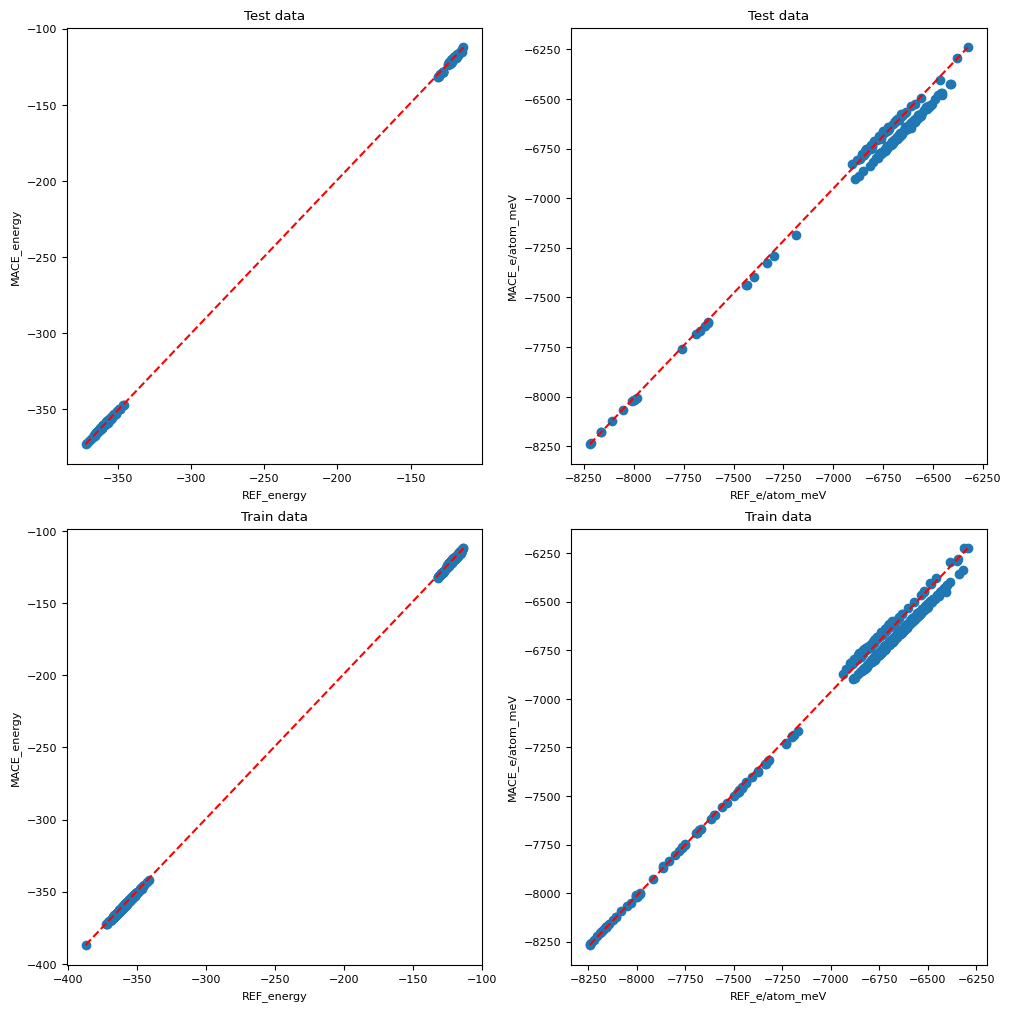

In [58]:
f.plot_comparison([test_df1, train_df1], 
                  ['REF_energy', 'REF_e/atom_meV'], ['MACE_energy','MACE_e/atom_meV'], ['Test data', 'Train data'], 'energy', model_name, path)

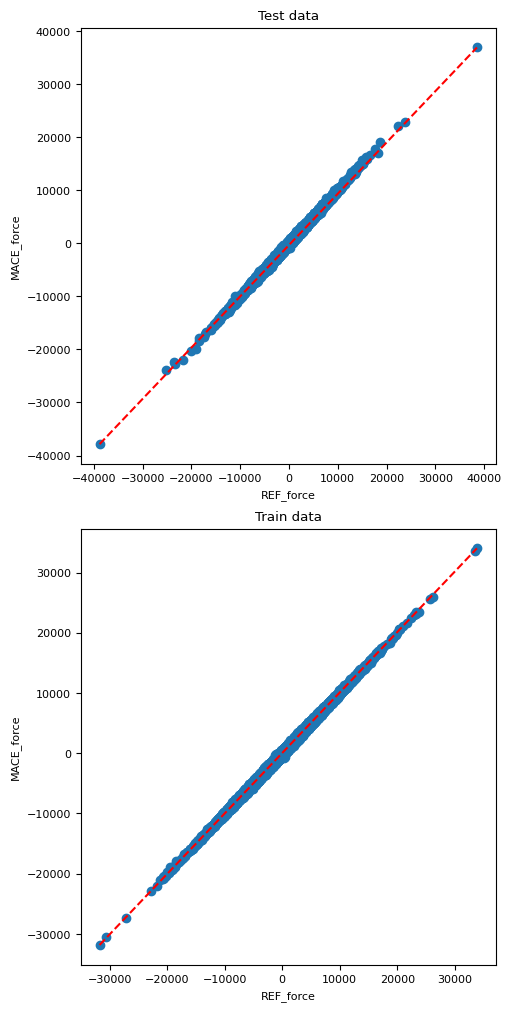

In [59]:
f.plot_comparison([test_df2, train_df2], 
                  ['REF_force'], ['MACE_force'], ['Test data', 'Train data'], 'forces', model_name, path)

In [60]:
ref = 'REF_e/atom_meV'
pred = 'MACE_e/atom_meV'
test_error = f.errors(test_df, 'test_energy', ref, pred)
train_error = f.errors(train_df, 'train_energy', ref, pred)
e_errors = pd.concat([test_error, train_error])
test_config_error = f.config_errors(test_df, 'test_energy', ref, pred)
train_config_error = f.config_errors(train_df, 'train_energy', ref, pred)
config_errors = pd.concat([test_config_error, train_config_error])
ref = 'REF_force'
pred = 'MACE_force'
test_error = f.errors(test_df2, 'test_force', ref, pred)
train_error = f.errors(train_df2, 'train_force', ref, pred)
f_errors = pd.concat([test_error, train_error])
errors = pd.concat([e_errors,f_errors])
errors

,error,rmse,mae,r2
0,test_energy,38.374589,28.255728,0.989806
0,train_energy,33.179509,24.184191,0.991838
0,test_force,160.316953,121.226438,0.996743
0,train_force,140.868010,108.554588,0.997468


In [61]:
#train_config_error

In [62]:
#test_config_error

In [63]:
#saving to an excel file so that we can keep a register of how different the resuls are for the different models
with pd.ExcelWriter(f'{path}/test_res/{model_name}_test.xlsx') as writer:
    test_df1.to_excel(writer, sheet_name='test_predictions')
    train_df1.to_excel(writer, sheet_name='train_predictions')
    errors.to_excel(writer, sheet_name='errors')
    config_errors.to_excel(writer, sheet_name='config_errors')